# Introduction to shell and Environment setup

A Shell is a program that lets you interact with the operating system using commands.

The file name with .sh is called as shell scripting file.

The file name reflecting in white colour is normal file.

The file name reflecting in green colour is excutable file.

To run shell script file : ./hell0.sh

For example, when I type a command like ls, the shell sends that command to the OS and shows me the output

For example, we use shell commands to manage servers, run scripts, and automate tasks in DevOps

👉 It acts as a bridge between:
    User 
    Operating System 

--->Types of Shells
Shell	     Description
bash	     Most commonly used (Linux default)
sh	         Basic shell
zsh	         Advanced features
fish	     User-friendly shell   

Environment setup :

1.Login to AWS.
2.Create instance.
3.Do the SSH from local to server.
4.Use linux-ubuntu terminal for command.

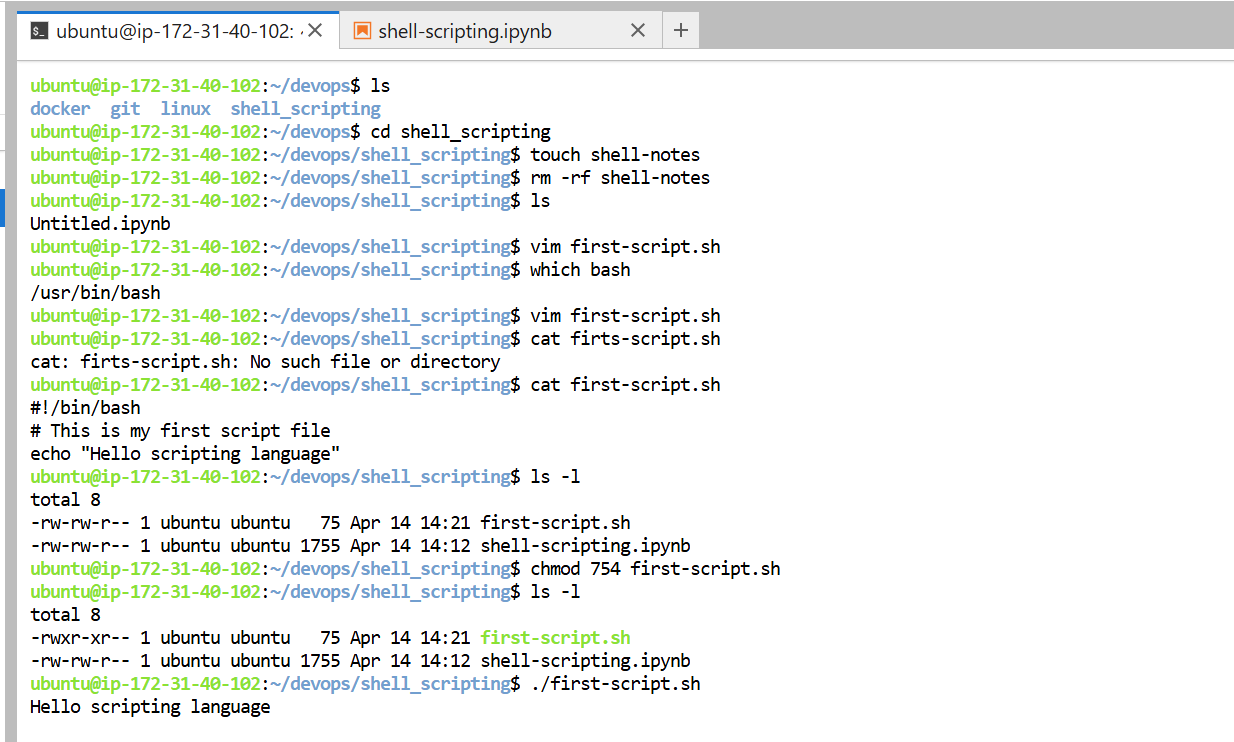

# Variables
A variable is used to store data (value) that can be reused in a script.
Variables are accessed using $ sign
If you want to run any command as a variable 
ex: $(date) current_date=$(date) echo $current_date

Created a script to create a username and added the user.
Real Example (User Creation Script)
#!/bin/bash

read -p "Enter Username: " username

echo "Username is $username"

sudo useradd $username

echo "New user is added"

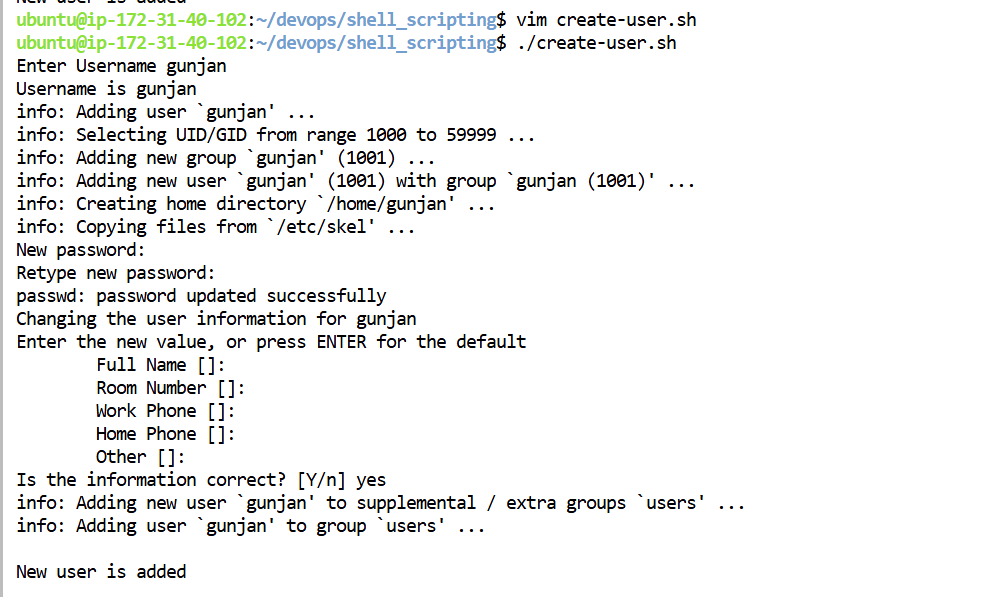

# Arguments 

Arguments are values passed to a script from the command line and accessed using $1, $2,etc.
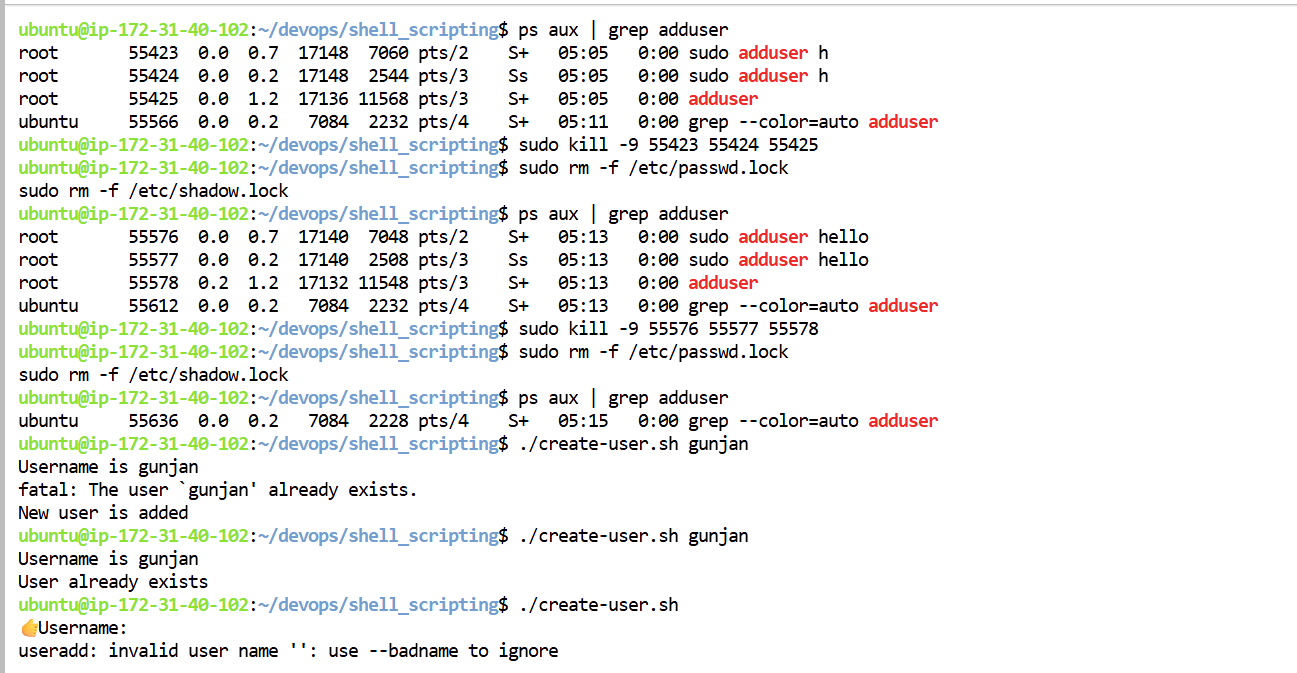


#Condition if else elif

if-else and elif are used in shell scripting to make decisions based on conditions. They help control the flow of execution depending on whether a condition is true or false."

if → check condition 
elif → check another condition 
else → default case

# Loop
Loop is used to repeat a task multiple times

1. for Loop
👉 Used when you know how many times to run
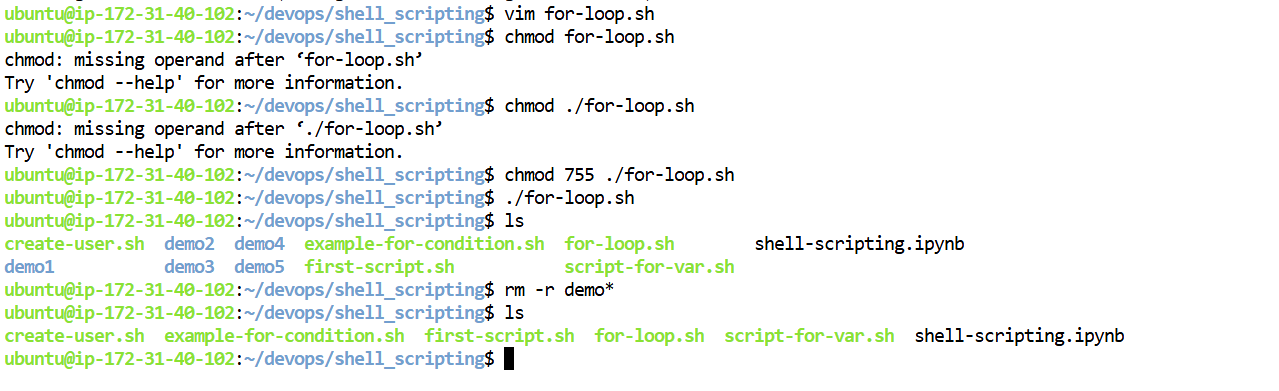

2. while Loop

👉 Used when condition is true
"In shell scripting, for loop is used when the number of iterations is known, while while loop runs based on a condition until it becomes false."

Note : In DevOps, we use loops and conditions in shell scripting to automate tasks like checking services, monitoring disk usage, retrying failed operations, and cleaning logs.

# Functions
A function is a block of code that:

Can be reused
Avoids repetition
Makes script clean

example :
#!/bin/bash

check_service() {
    service=$1

    if systemctl is-active --quiet $service; then
        echo "$service is running ✅"
    else
        echo "$service is NOT running ❌"
    fi
}

check_service ssh
check_service nginx


Functions are used to create reusable blocks of code in shell scripting, which helps in reducing repetition and improving script readability

# Basic script for Devops

In DevOps, we use shell scripts with loops and conditions to automate tasks like monitoring services, checking disk usage, cleaning logs, and retrying failed operations.

# 1. Service Check Script

service="ssh"

if systemctl is-active --quiet $service; then
    echo "$service is running ✅"
else
    echo "$service is NOT running ❌"
fi
🧠 Explanation

👉 service="ssh"
→ Store service name in variable

👉 systemctl is-active --quiet $service
→ Checks if service is running
→ --quiet hides output

👉 if ...; then
→ If service is running ✔

👉 else
→ If not running ❌

🎯 Real Use
Check if server services (nginx, ssh, docker) are running


# 2. Auto Restart Script

if systemctl is-active --quiet $service; then
    echo "$service is running"
else
    echo "$service is down, restarting..."
    sudo systemctl restart $service
fi
🧠 Explanation

👉 Same check as above
👉 If service is down:

sudo systemctl restart $service

→ Restart service automatically 🔥

# 3. Disk Usage Script

usage=$(df -h / | awk 'NR==2 {print $5}' | sed 's/%//')
🧠 Step-by-step

👉 df -h /
→ Shows disk usage

👉 awk 'NR==2 {print $5}'
→ Takes 2nd line → 5th column (usage %)

👉 sed 's/%//'
→ Removes % symbol

👉 usage=...
→ Store result in variable

Next part:
if [ $usage -gt 80 ]; then

👉 If usage > 80%

🎯 Real Use
Alert when disk is full

# 4. Log Cleanup Script

In shell scripting, if no files match a wildcard like *.log, it is treated as a literal string. We handle this using checks or enabling nullglob.

for file in *.log
do
    echo "Deleting $file"
    rm -f $file
done
🧠 Explanation

👉 for file in *.log
→ Loop through all .log files

👉 rm -f $file
→ Delete file

🎯 Real Use
Delete old logs to save disk space

# Intermediate Scripting Techniques

# Error Handling

In shell scripting, error handling is done using exit status $?, conditional checks, and commands like set -e to stop execution on failure. It ensures scripts run safely and handle failures properly.


🔹 1. Exit Script on Error (exit)
#!/bin/bash

mkdir test || {
    echo "Error creating directory"
    exit 1
}

👉 If command fails → script stops ❌

🔹 2. set -e (AUTO EXIT 🔥)
#!/bin/bash
set -e

mkdir test
mkdir test2

👉 If any command fails → script stops automatically

3. Custom Error Function (PRO LEVEL)
#!/bin/bash

error_exit() {
    echo "Error: $1"
    exit 1
}

mkdir test || error_exit "Directory creation failed"

----------------Real DevOps Example---------------------
#!/bin/bash

systemctl restart nginx || {
    echo "Failed to restart nginx ❌"
    exit 1
}

echo "Service restarted successfully ✅"


----------------Interview Answer (Use This 🔥)----------------------------

"I created a shell script using functions and error handling to check user existence, service status, and disk usage. I used reusable functions and exit conditions to make the script robust and reliable."

🚀 Why This is Powerful

✔ Real DevOps logic
✔ Uses functions
✔ Uses error handling
✔ Uses conditions
✔ Uses arguments

#!/bin/bash

# 🔹 Error function
error_exit() {
    echo "❌ Error: $1"
    exit 1
}

# 🔹 Check user
check_user() {
    user=$1

    if id "$user" &>/dev/null; then
        echo "✅ User exists: $user"
    else
        error_exit "User $user not found"
    fi
}

# 🔹 Check service
check_service() {
    service=$1

    if systemctl is-active --quiet "$service"; then
        echo "✅ Service running: $service"
    else
        echo "⚠️ Service not running: $service"
        sudo systemctl restart "$service" || error_exit "Failed to restart $service"
    fi
}

# 🔹 Check disk
check_disk() {
    usage=$(df -h / | awk 'NR==2 {print $5}' | sed 's/%//')

    echo "Disk usage: $usage%"

    if [ "$usage" -gt 80 ]; then
        error_exit "Disk usage is high"
    else
        echo "✅ Disk is under control"
    fi
}

# 🔹 MAIN

check_user "$1"
check_service "$2"
check_disk

echo "🎉 All checks completed successfully"

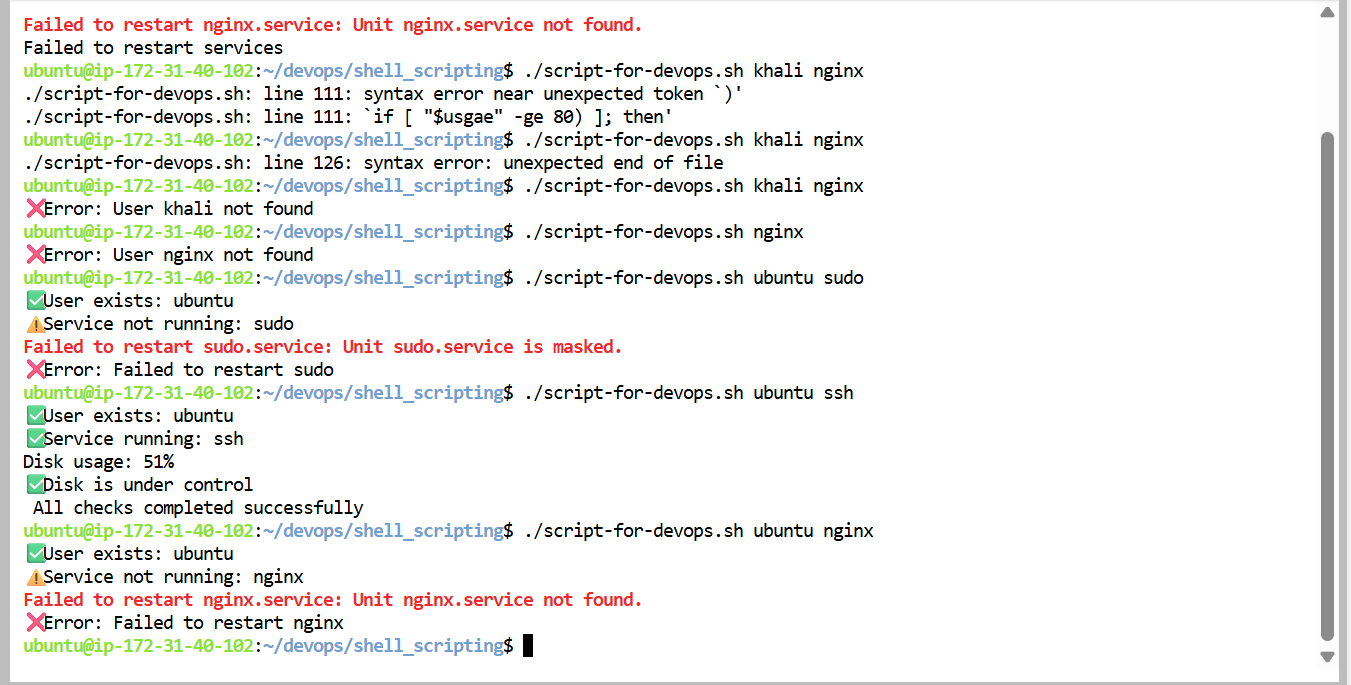

# AWS linking to shell 

Install AWS CLI → Configure → Write Script → Control AWS (EC2, S3)

I use AWS CLI inside shell scripts to automate tasks like creating EC2 instances, managing S3 buckets, and deploying applications. This helps in automating cloud operations efficiently.

Install AWS CLI->configure->

STEP 3:create bucket using shell script(easy to crate through AWS UI)

#!/bin/bash

bucket_name="gunjan-devops-bucket"

aws s3 mb s3://$bucket_name || {
    echo "❌ Failed to create bucket"
    exit 1
}

echo "✅ Bucket created: $bucket_name"

STEP 4: Upload File to S3

#!/bin/bash

file="test.txt"
bucket="gunjan-devops-bucket"

if [ ! -f "$file" ]; then
    echo "❌ File not found"
    exit 1
fi

aws s3 cp "$file" s3://$bucket/ || {
    echo "❌ Upload failed"
    exit 1
}

echo "✅ File uploaded"

STEP 6: Create EC2 Instance (IMPORTANT 🔥)

👉 Script: create-ec2.sh

#!/bin/bash

ami="ami-0abcdef12345"   # change based on region ami-0c33c6bd24cee108b
instance_type="t2.micro" t3.micro
key_name="your-keypair" linux_for_devops_key

aws ec2 run-instances \
--image-id $ami \
--count 1 \
--instance-type $instance_type \
--key-name $key_name || {
    echo "❌ EC2 creation failed"
    exit 1
}

echo "✅ EC2 instance created"

STEP 7: Start EC2
#!/bin/bash

instance_id="i-xxxxxxxx"

aws ec2 start-instances --instance-ids $instance_id || {
    echo "❌ Failed to start EC2"
    exit 1
}

echo "✅ EC2 started"

STEP 8: Stop EC2
#!/bin/bash

instance_id="i-xxxxxxxx"

aws ec2 stop-instances --instance-ids $instance_id

STEP 9: Check EC2 Status
aws ec2 describe-instances

I use AWS CLI inside shell scripts to automate tasks like creating EC2 instances, managing S3 buckets, and deploying applications. This helps in automating cloud operations efficiently.

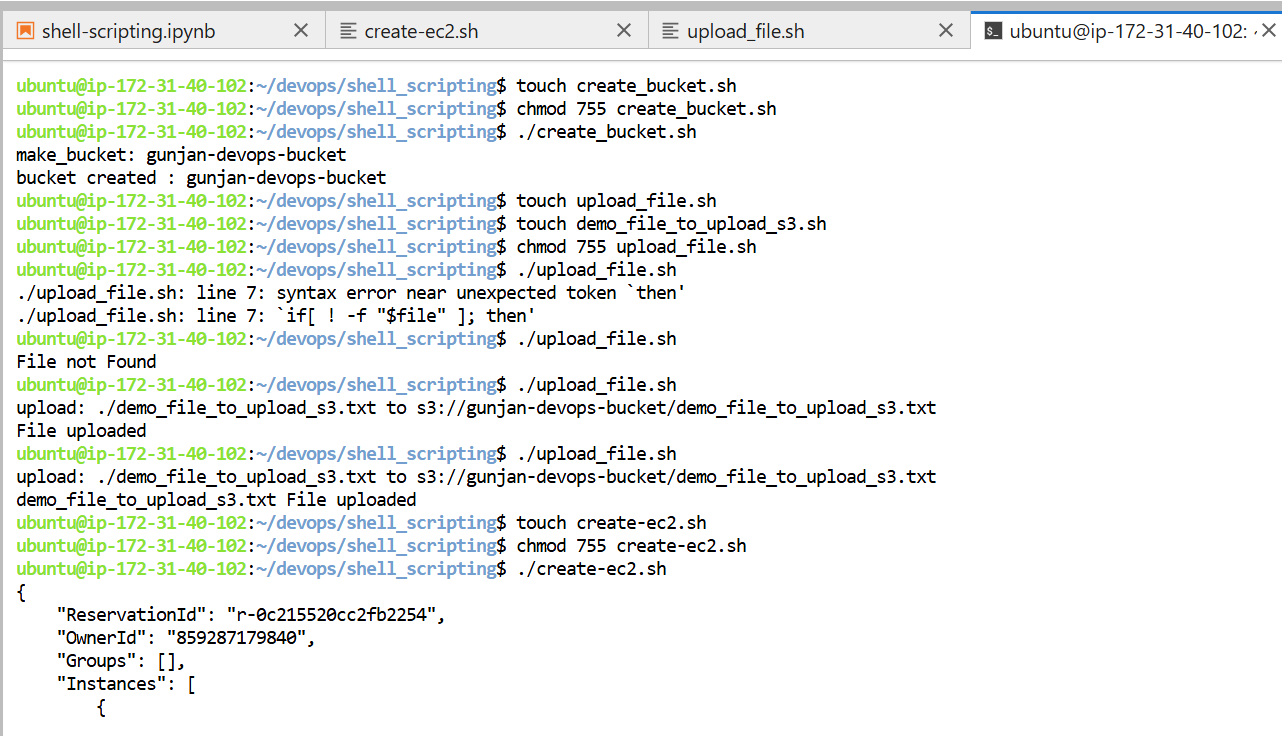